# Centroid Tracking for a single video

Video FPS: 27.00, Frames: 39976, Duration: 1480.59 sec, Frame height: 1160
Estimated background HSV: 42.6, 203.3, 248.3
Using background mask range: (22, 123, 168) – (62, 255, 255)
Runtime: 0:00:18.182321


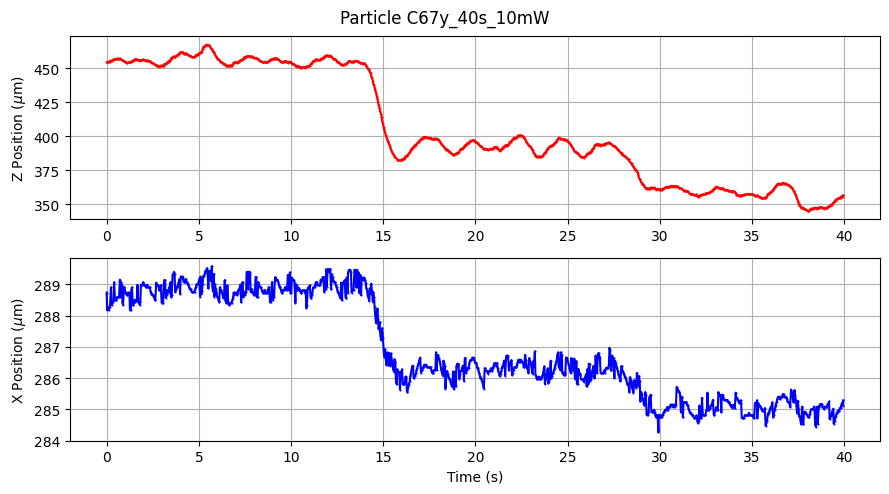

In [30]:
import cv2
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
start = datetime.now()

particle = "C67"
#video_name = fr"{particle}_sweep_1"
video_name = fr"{particle}y_40s_10mW"

video_path  = fr"A:\LML\Videos\xz\{video_name}.wmv"
output_csv  = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{video_name}.csv"
output_plot = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{video_name}.png"

#ROI
x0, y0, w, h = 300, 0, 300, 1160
speedup = 50  # playback speed multiplier
con_fac = 1/1.7625 # (um/pixel) conversion factor

# VIDEO
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
fps= 27.0
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps if fps > 0 else 0.0
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video FPS: {fps:.2f}, Frames: {frame_count}, Duration: {duration:.2f} sec, Frame height: {frame_height}")

# PRECOMPUTE TIME ARRAY (one entry per frame index 0..frame_count-1)
if frame_count > 0:
    time_array = np.linspace(0.0, duration, frame_count, endpoint=False)
else:
    time_array = np.array([0.0])

# BACKGROUND COLOR CALIBRATION
samples = []
for _ in range(10):
    ret, frame = cap.read()
    if not ret:
        break
    roi = frame[y0:y0+h, x0:x0+w]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    samples.append(cv2.mean(hsv)[:3])
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

if len(samples) == 0:
    raise RuntimeError("Couldn't read frames for background calibration. Check ROI and video.")

bg_h, bg_s, bg_v = np.mean(samples, axis=0)
print(f"Estimated background HSV: {bg_h:.1f}, {bg_s:.1f}, {bg_v:.1f}")

h_tol, s_tol, v_tol = 20, 80, 80
bg_lower = (max(0, bg_h - h_tol), max(0, bg_s - s_tol), max(0, bg_v - v_tol))
bg_upper = (min(179, bg_h + h_tol), min(255, bg_s + s_tol), min(255, bg_v + v_tol))
bg_lower = tuple(map(int, bg_lower))
bg_upper = tuple(map(int, bg_upper))

print(f"Using background mask range: {bg_lower} – {bg_upper}")

# OUTPUT FILE
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Time (s)", "X_pos (um)", "Z_pos (um)"])

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # --- Determine a robust timestamp 't' for the frame we just read ---
        # Prefer POS_MSEC (milliseconds) if available; otherwise use POS_FRAMES -> index into time_array
        pos_msec = cap.get(cv2.CAP_PROP_POS_MSEC)
        if pos_msec and pos_msec > 0.5:
            t = pos_msec / 1000.0
        else:
            pos_frame = cap.get(cv2.CAP_PROP_POS_FRAMES)
            # Many backends report the next frame index, so subtract 1 to get the frame we just read.
            # Round to nearest int then -1. Clamp index to valid range.
            idx = int(round(pos_frame)) - 1
            if idx < 0:
                idx = 0
            if idx >= len(time_array):
                idx = len(time_array) - 1
            t = float(time_array[idx])
        frame_idx += 1

        # Extract ROI
        roi = frame[y0:y0+h, x0:x0+w]
        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

        # Mask generation
        bg_mask = cv2.inRange(hsv, bg_lower, bg_upper)
        particle_mask = cv2.bitwise_not(bg_mask)

        # Clean up mask
        kernel = np.ones((3, 3), np.uint8)
        particle_mask = cv2.morphologyEx(particle_mask, cv2.MORPH_OPEN, kernel)
        particle_mask = cv2.morphologyEx(particle_mask, cv2.MORPH_CLOSE, kernel)

        # Find contours
        contours, _ = cv2.findContours(particle_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            if cv2.contourArea(c) > 15:
                M = cv2.moments(c)
                if M["m00"] > 0:
                    cx = int(M["m10"] / M["m00"] + x0)
                    cy = int(M["m01"] / M["m00"] + y0)
                    cy_flipped = (frame_height - cy)
                    # write the robust timestamp 't' to CSV
                    writer.writerow([t, cx *con_fac, cy_flipped*con_fac])

                    # Draw centroid
                    cv2.circle(frame, (cx, cy), 8, (0, 0, 0), 2)
                    cv2.circle(frame, (cx, cy), 6, (0, 255, 255), -1)

        # Draw ROI rectangle
        cv2.rectangle(frame, (x0, y0), (x0 + w, y0 + h), (0, 0, 255), 2)

        # video time overlay
        time_text = f"t = {t:.3f} s"
        cv2.putText(frame, time_text, (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2)

        # Visualization (ROI-proportional display)
        # Convert mask to 3-channel and resize proportionally to ROI shape
        mask_vis = cv2.cvtColor(particle_mask, cv2.COLOR_GRAY2BGR)
        aspect_ratio = h / w
        display_height = 500
        display_width = int(display_height / aspect_ratio)
        if display_width <= 0:
            display_width = 200
        mask_vis = cv2.resize(mask_vis, (display_width, display_height))

        # Resize full frame to same display height
        frame_vis = cv2.resize(frame, (int(frame.shape[1] * display_height / frame.shape[0]), display_height))

        combined = np.hstack([mask_vis, frame_vis]) # Combined side by side

        cv2.imshow("Tracking (Left: ROI Mask | Right: Full Frame)", combined)

        if cv2.waitKey(max(1, int(1000 / (fps * speedup)))) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
print(f"Runtime: {datetime.now() - start}")

# SAVE & PLOT RESULTS
data = pd.read_csv(output_csv)

if len(data) == 0:
    print("⚠️ No data recorded — adjust ROI or mask tolerances.")
else:
    t = data["Time (s)"].values
    x = data["X_pos (um)"].values
    z = data["Z_pos (um)"].values

    theta = 8.368*np.pi/180
    R = np.array([[np.cos(theta),  np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])

    x, z = R @ np.vstack((x, z))
    if np.min(z) < 0:
        z = z - np.min(z)
        z[np.abs(z) < 1e-6] = 0

    corrected_df = pd.DataFrame({"Time (s)": t, "X_pos (um)": x, "Z_pos (um)": z})
    corrected_df.to_csv(output_csv, index=False)
    
    plt.figure(figsize=(9, 5))

    plt.subplot(2, 1, 1)
    plt.plot(t, z, "r.-", markersize=1)
    plt.ylabel("Z Position ($\\mu$m)")
    plt.title(" ")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t, x, "b.-", markersize=1)
    plt.xlabel("Time (s)")
    plt.ylabel("X Position ($\\mu$m)")
    plt.grid(True)

    plt.tight_layout()
    plt.suptitle(f"Particle {video_name}")
    plt.savefig(output_plot, dpi=500)
    plt.show()


# Centroid Tracking for all videos of a single particle


=== Processing C67y_40s_10mW ===
Video FPS: 27.00, Frames: 39976, Duration: 1480.59 sec, Frame height: 1160
Estimated background HSV: 42.6, 203.3, 248.3
Using background mask range: (22, 123, 168) – (62, 255, 255)


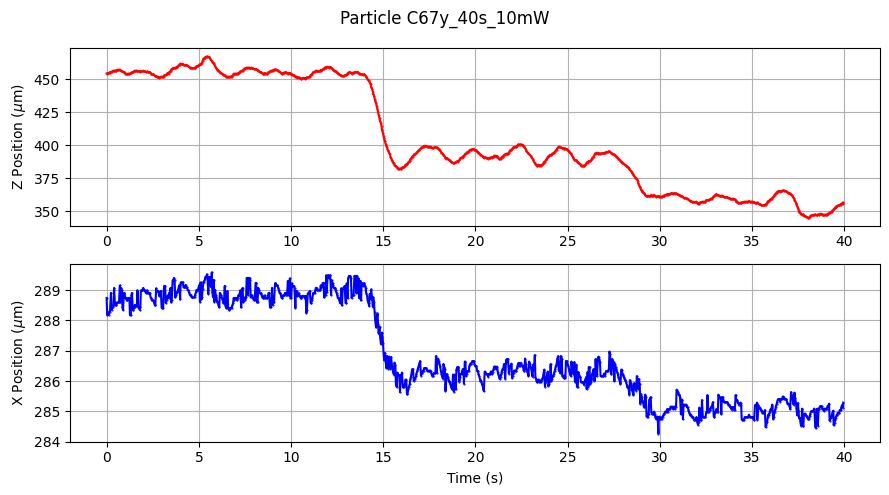


=== Processing C67y_40s_7mW ===
Video FPS: 27.00, Frames: 40038, Duration: 1482.89 sec, Frame height: 1160
Estimated background HSV: 42.4, 208.2, 248.4
Using background mask range: (22, 128, 168) – (62, 255, 255)


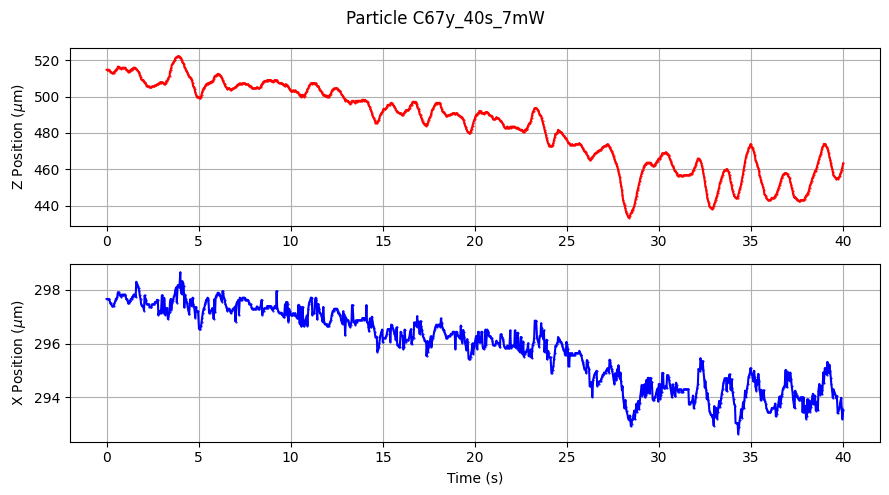


=== Processing C67y_40s_5mW ===
Video FPS: 27.00, Frames: 40007, Duration: 1481.74 sec, Frame height: 1160
Estimated background HSV: 42.2, 211.3, 249.4
Using background mask range: (22, 131, 169) – (62, 255, 255)


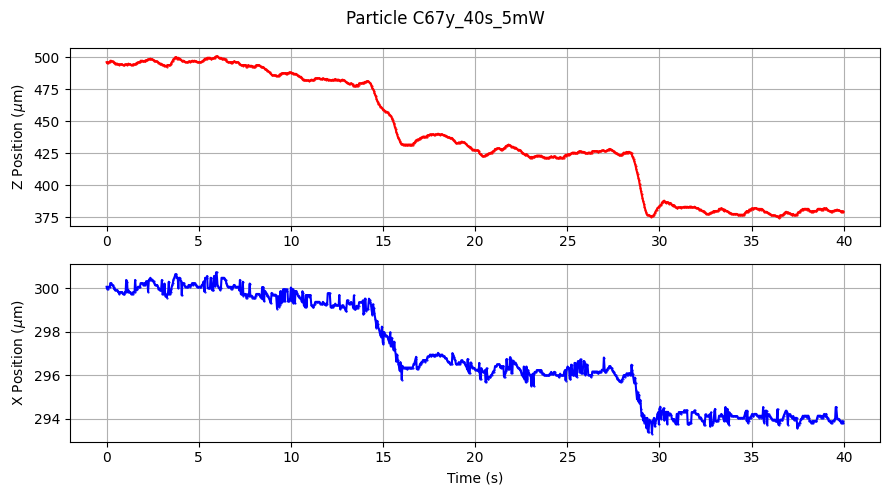


=== Processing C67y_40s_4mW ===
Video FPS: 27.00, Frames: 40007, Duration: 1481.74 sec, Frame height: 1160
Estimated background HSV: 42.1, 212.7, 249.9
Using background mask range: (22, 132, 169) – (62, 255, 255)


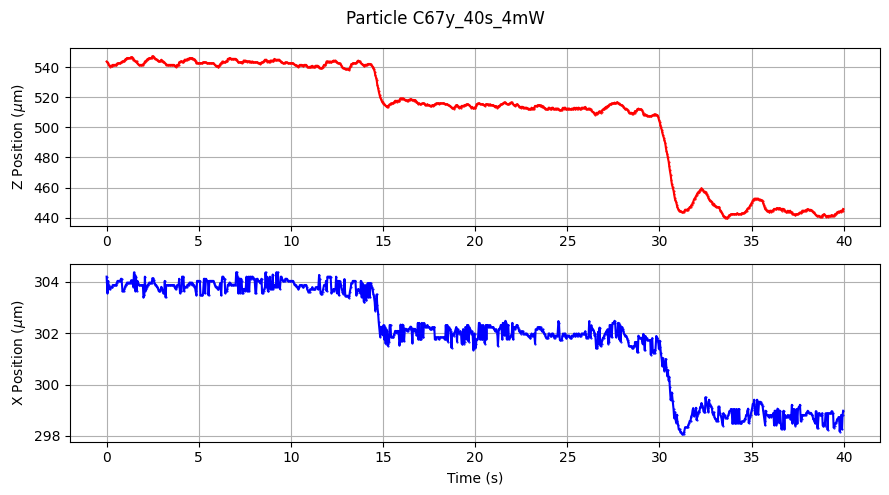


=== Processing C67y_40s_3mW ===
Video FPS: 27.00, Frames: 40022, Duration: 1482.30 sec, Frame height: 1160
Estimated background HSV: 42.0, 220.5, 249.8
Using background mask range: (21, 140, 169) – (61, 255, 255)


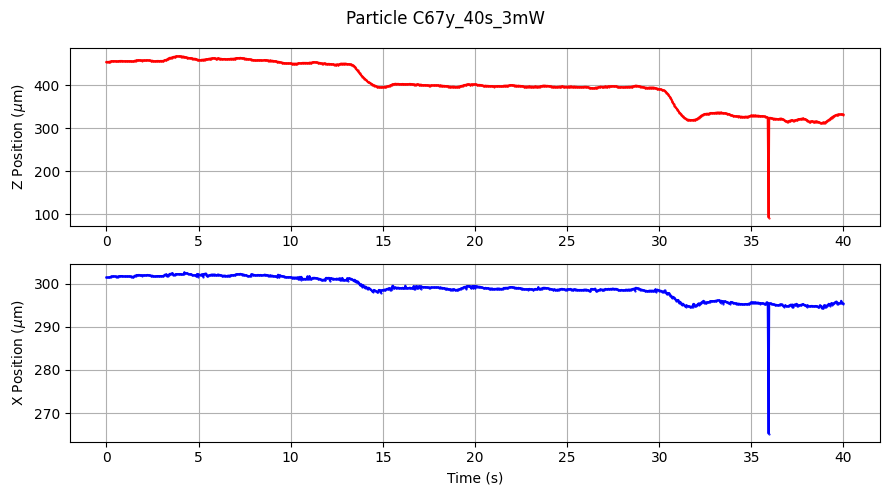


=== Processing C67_sweep_1 ===
Video FPS: 27.00, Frames: 60007, Duration: 2222.48 sec, Frame height: 1160
Estimated background HSV: 42.3, 202.5, 249.7
Using background mask range: (22, 122, 169) – (62, 255, 255)


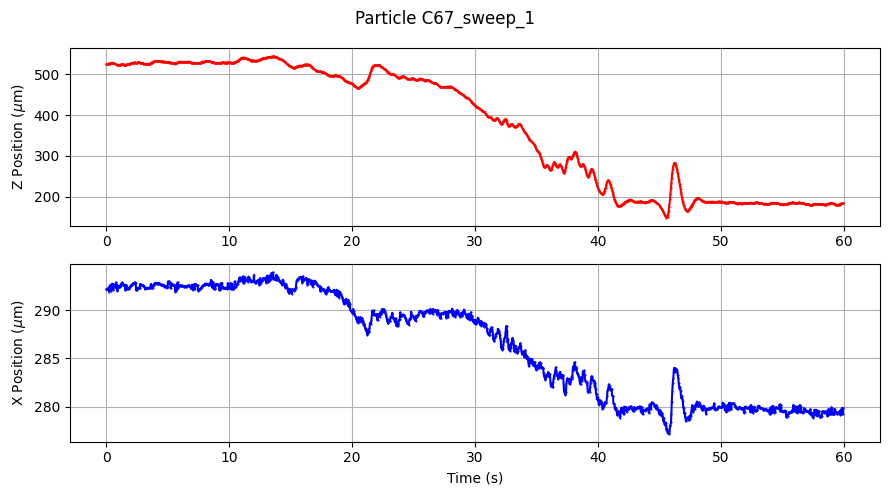


=== Processing C67_sweep_2 ===
Video FPS: 27.00, Frames: 59991, Duration: 2221.89 sec, Frame height: 1160
Estimated background HSV: 42.6, 204.2, 247.8
Using background mask range: (22, 124, 167) – (62, 255, 255)


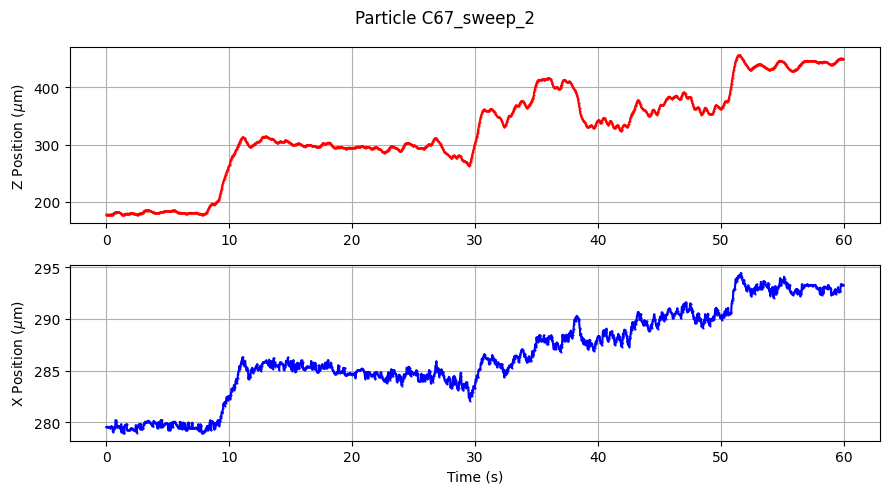


=== Processing C67_sweep_3 ===
Video FPS: 27.00, Frames: 59991, Duration: 2221.89 sec, Frame height: 1160
Estimated background HSV: 42.5, 208.5, 248.1
Using background mask range: (22, 128, 168) – (62, 255, 255)


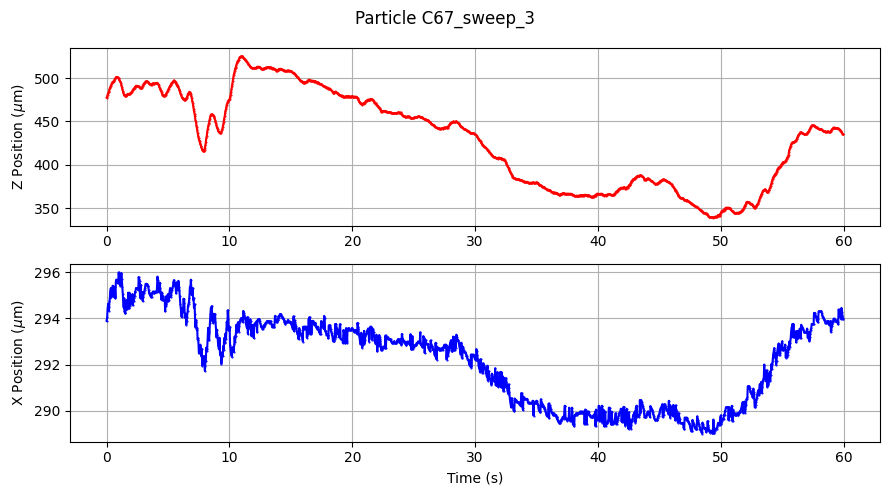


=== Processing C67_sweep_4 ===
Video FPS: 27.00, Frames: 60007, Duration: 2222.48 sec, Frame height: 1160
Estimated background HSV: 42.2, 207.5, 249.5
Using background mask range: (22, 127, 169) – (62, 255, 255)


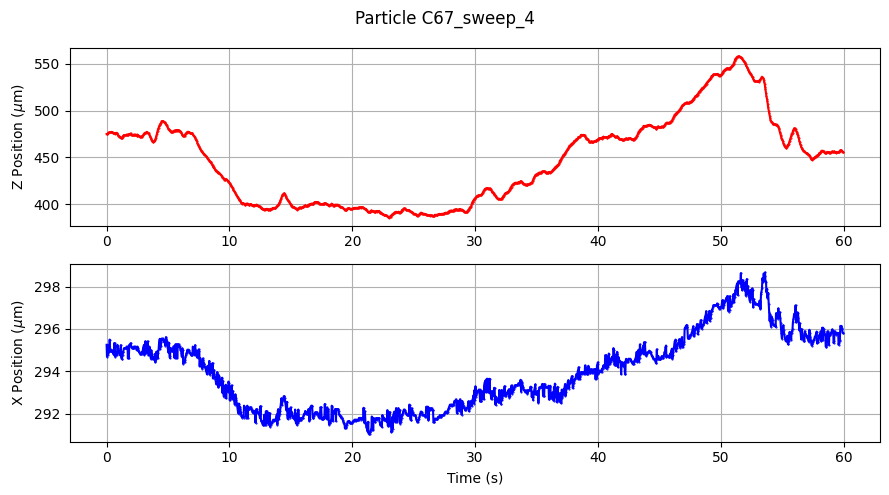


=== Processing C67_sweep_5 ===
Video FPS: 27.00, Frames: 60006, Duration: 2222.44 sec, Frame height: 1160
Estimated background HSV: 42.3, 211.8, 249.0
Using background mask range: (22, 131, 168) – (62, 255, 255)


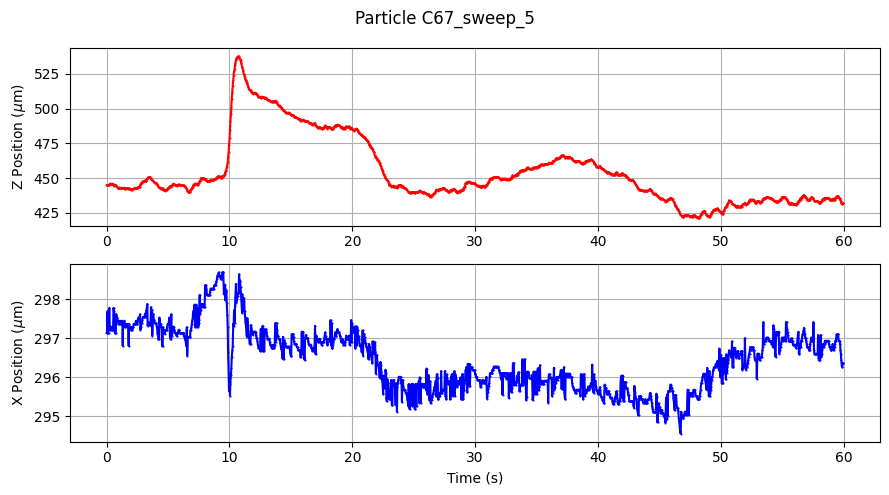


=== Processing C67_sweep_6 ===
Video FPS: 27.00, Frames: 60022, Duration: 2223.04 sec, Frame height: 1160
Estimated background HSV: 42.4, 212.0, 248.7
Using background mask range: (22, 132, 168) – (62, 255, 255)


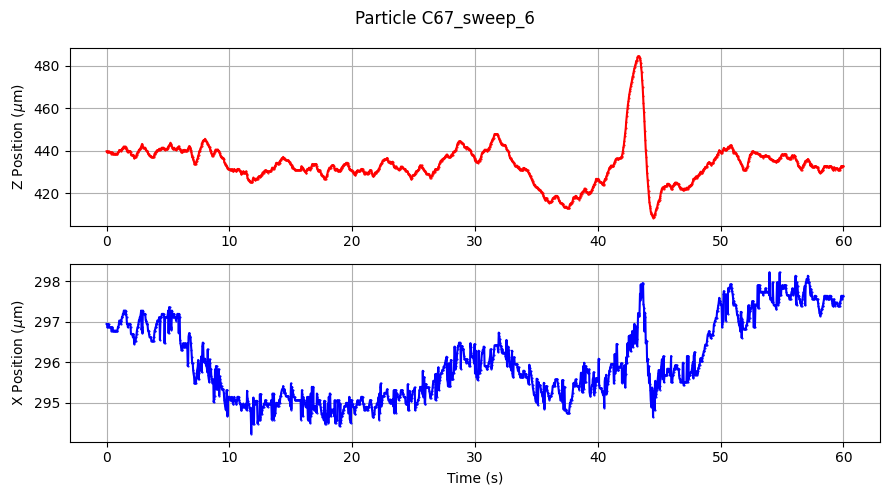


=== Processing C67_sweep_7 ===
Video FPS: 27.00, Frames: 59976, Duration: 2221.33 sec, Frame height: 1160
Estimated background HSV: 42.2, 213.7, 249.4
Using background mask range: (22, 133, 169) – (62, 255, 255)


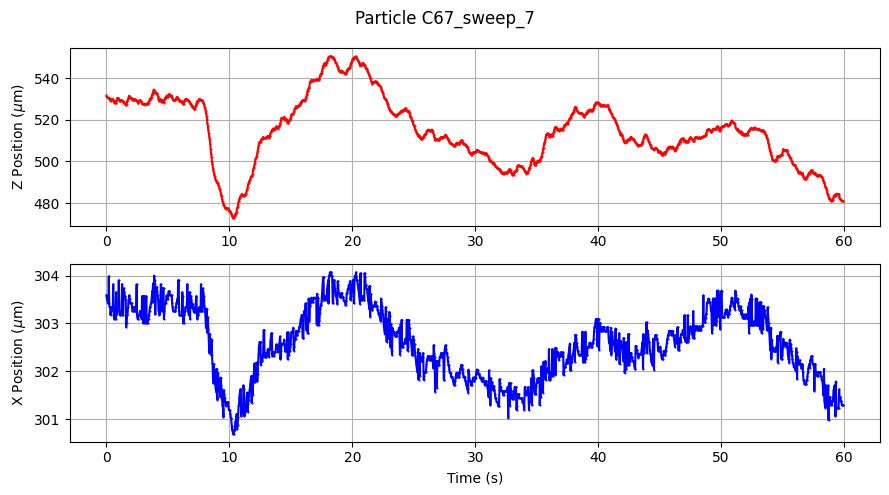


=== Processing C67_sweep_8 ===
Video FPS: 27.00, Frames: 59975, Duration: 2221.30 sec, Frame height: 1160
Estimated background HSV: 42.1, 214.6, 249.4
Using background mask range: (22, 134, 169) – (62, 255, 255)


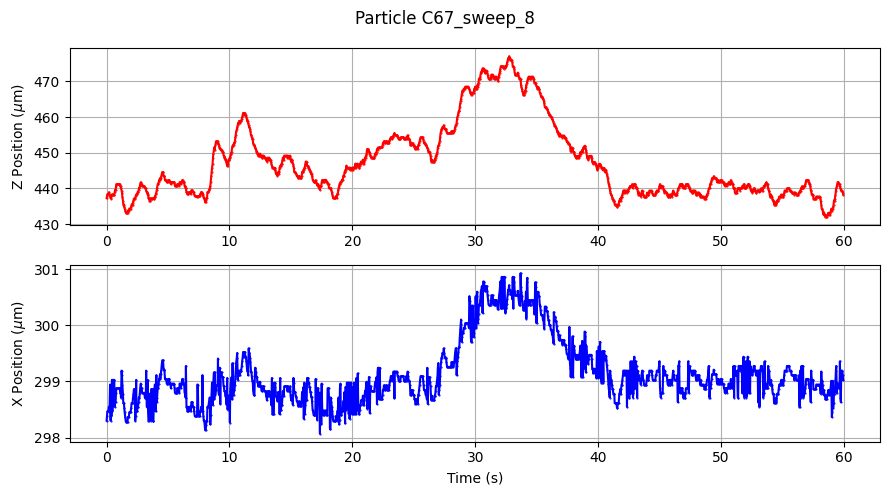


=== Processing C67_sweep_9 ===
Video FPS: 27.00, Frames: 59991, Duration: 2221.89 sec, Frame height: 1160
Estimated background HSV: 41.7, 220.9, 250.6
Using background mask range: (21, 140, 170) – (61, 255, 255)


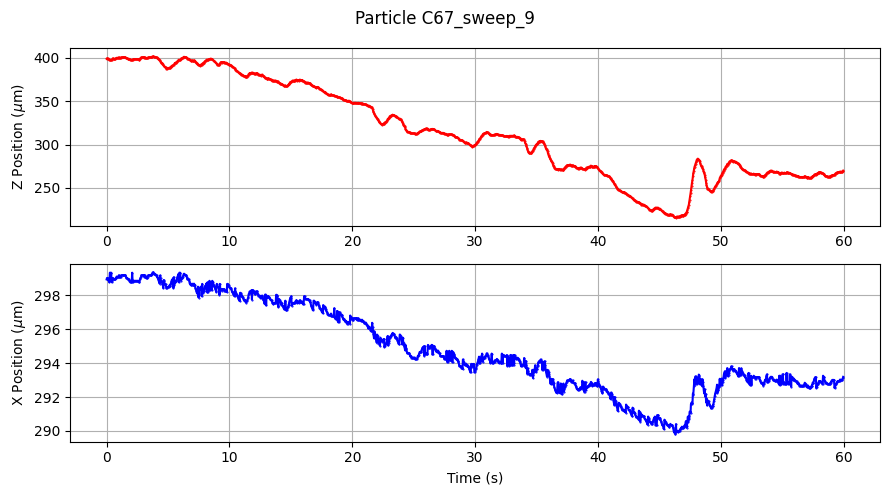


=== Processing C67_sweep_10 ===
Video FPS: 27.00, Frames: 60007, Duration: 2222.48 sec, Frame height: 1160
Estimated background HSV: 41.9, 222.9, 249.4
Using background mask range: (21, 142, 169) – (61, 255, 255)


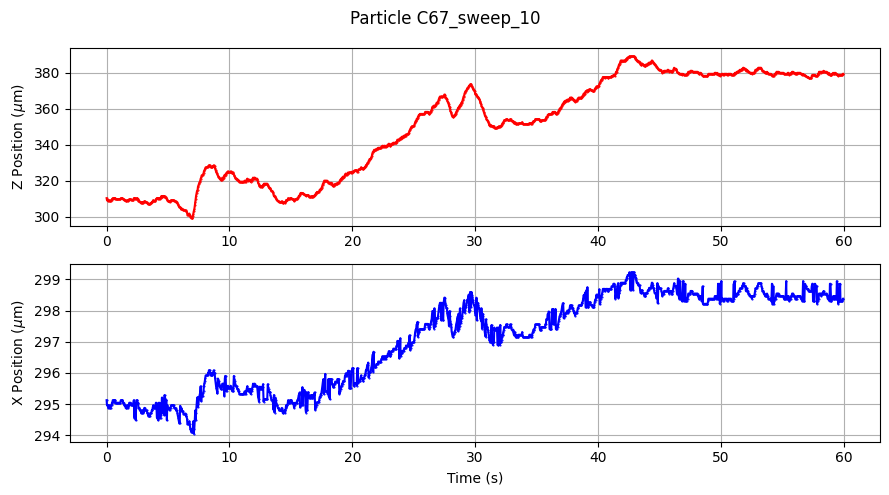


Total runtime: 0:06:19.839472


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import csv
import os
from datetime import datetime
start = datetime.now()

particle = "C67"

# ROI
x0, y0, w, h = 300, 0, 300, 1160
speedup = 50
con_fac = 1/1.7625  # um/pixel
camera_tilt = 8.368

sweep_numbers = range(1, 11)
powers = [10, 7, 5, 4, 3]

video_jobs = []

# power 
for p in powers:
    name = f"{particle}y_40s_{p}mW"
    path = fr"A:\LML\Videos\xz\{name}.wmv"
    video_jobs.append((name, path))
    
# sweep
for n in sweep_numbers:
    name = f"{particle}_sweep_{n}"
    path = fr"A:\LML\Videos\xz\{name}.wmv"
    video_jobs.append((name, path))

for video_name, video_path in video_jobs:

    if not os.path.exists(video_path):
        print(f"⚠️ Skipping missing file: {video_path}")
        continue

    print(f"\n=== Processing {video_name} ===")

    # OUTPUT FILES
    video_stem = os.path.splitext(os.path.basename(video_path))[0]
    output_dir = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}"
    os.makedirs(output_dir, exist_ok=True)

    output_csv  = os.path.join(output_dir, f"{video_stem}.csv")
    output_plot = os.path.join(output_dir, f"{video_stem}.png")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"⚠️ Cannot open video: {video_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    fps = 27.0
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps > 0 else 0.0
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Video FPS: {fps:.2f}, Frames: {frame_count}, Duration: {duration:.2f} sec, Frame height: {frame_height}")

    # time array
    if frame_count > 0:
        time_array = np.linspace(0.0, duration, frame_count, endpoint=False)
    else:
        time_array = np.array([0.0])

    # Bg calibration
    samples = []
    for _ in range(10):
        ret, frame = cap.read()
        if not ret:
            break
        roi = frame[y0:y0+h, x0:x0+w]
        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        samples.append(cv2.mean(hsv)[:3])
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    if len(samples) == 0:
        print("⚠️ Background calibration failed.")
        cap.release()
        continue

    bg_h, bg_s, bg_v = np.mean(samples, axis=0)
    print(f"Estimated background HSV: {bg_h:.1f}, {bg_s:.1f}, {bg_v:.1f}")

    h_tol, s_tol, v_tol = 20, 80, 80
    bg_lower = (max(0, bg_h - h_tol),
                max(0, bg_s - s_tol),
                max(0, bg_v - v_tol))
    bg_upper = (min(179, bg_h + h_tol),
                min(255, bg_s + s_tol),
                min(255, bg_v + v_tol))
    bg_lower = tuple(map(int, bg_lower))
    bg_upper = tuple(map(int, bg_upper))

    print(f"Using background mask range: {bg_lower} – {bg_upper}")

    # tracking
    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Time (s)", "X_pos (um)", "Z_pos (um)"])
        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            # timestamp
            pos_msec = cap.get(cv2.CAP_PROP_POS_MSEC)
            if pos_msec and pos_msec > 0.5:
                t = pos_msec / 1000.0
            else:
                pos_frame = cap.get(cv2.CAP_PROP_POS_FRAMES)
                idx = int(round(pos_frame)) - 1
                idx = max(0, min(idx, len(time_array) - 1))
                t = float(time_array[idx])
            frame_idx += 1
            
            # ROI
            roi = frame[y0:y0+h, x0:x0+w]
            hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

            bg_mask = cv2.inRange(hsv, bg_lower, bg_upper)
            particle_mask = cv2.bitwise_not(bg_mask)

            kernel = np.ones((3, 3), np.uint8)
            particle_mask = cv2.morphologyEx(particle_mask, cv2.MORPH_OPEN, kernel)
            particle_mask = cv2.morphologyEx(particle_mask, cv2.MORPH_CLOSE, kernel)

            contours, _ = cv2.findContours(particle_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if contours:
                c = max(contours, key=cv2.contourArea)
                if cv2.contourArea(c) > 15:
                    M = cv2.moments(c)
                    if M["m00"] > 0:
                        cx = int(M["m10"] / M["m00"] + x0)
                        cy = int(M["m01"] / M["m00"] + y0)
                        cy_flipped = frame_height - cy
                        writer.writerow([t, cx*con_fac, cy_flipped*con_fac])

                        cv2.circle(frame, (cx, cy), 8, (0, 0, 0), 2)
                        cv2.circle(frame, (cx, cy), 6, (0, 255, 255), -1)

            cv2.rectangle(frame, (x0, y0), (x0+w, y0+h), (0, 0, 255), 2)

            time_text = f"t = {t:.3f} s"
            cv2.putText(frame, time_text, (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2)

            mask_vis = cv2.cvtColor(particle_mask, cv2.COLOR_GRAY2BGR)
            aspect_ratio = h / w
            display_height = 500
            display_width = max(200, int(display_height / aspect_ratio))
            mask_vis = cv2.resize(mask_vis, (display_width, display_height))

            frame_vis = cv2.resize(frame, (int(frame.shape[1] * display_height / frame.shape[0]), display_height))

            combined = np.hstack([mask_vis, frame_vis])
            cv2.imshow("Tracking (Left: ROI Mask | Right: Full Frame)", combined)

            if cv2.waitKey(max(1, int(1000 / (fps * speedup)))) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()

    data = pd.read_csv(output_csv)

    if len(data) == 0:
        print("⚠️ No data recorded.")
        continue

    t = data["Time (s)"].values
    x = data["X_pos (um)"].values
    z = data["Z_pos (um)"].values
    
    theta = np.deg2rad(camera_tilt)
    R = np.array([[np.cos(theta),  np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])

    x, z = R @ np.vstack((x, z))
    if np.min(z) < 0:
        z = z - np.min(z)
        z[np.abs(z) < 1e-6] = 0
    corrected_df = pd.DataFrame({"Time (s)": t, "X_pos (um)": x, "Z_pos (um)": z})
    corrected_df.to_csv(output_csv, index=False)

    plt.figure(figsize=(9, 5))

    plt.subplot(2, 1, 1)
    plt.plot(t, z, "r.-", markersize=1)
    plt.ylabel("Z Position ($\\mu$m)")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t, x, "b.-", markersize=1)
    plt.xlabel("Time (s)")
    plt.ylabel("X Position ($\\mu$m)")
    plt.grid(True)

    plt.suptitle(f"Particle {video_name}")
    plt.tight_layout()
    #plt.savefig(output_plot, dpi=500)
    plt.show()

print(f"\nTotal runtime: {datetime.now() - start}")

# Centroid Data Analysis

Y1:  292.11 µm, X:   114.34 µm, Y2:  313.51 µm
ND1: 409.94 µm, ND2: 340.45 µm, ND3: 305.45 µm

Runtime: 0:00:00.437037


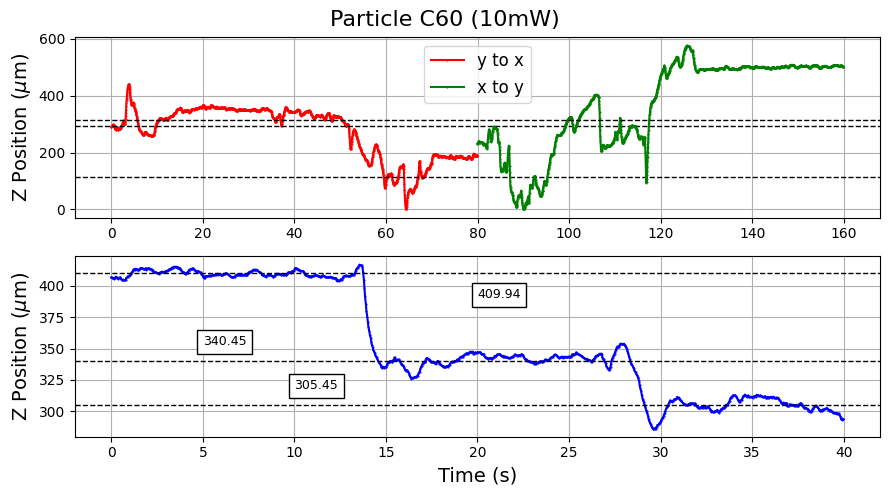

In [3]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from datetime import datetime
start = datetime.now()

def plot2(data_1, data_2, data_3, particle, output_plot, power, y1_range, x_range, y2_range, ND_range1, ND_range2, ND_range3):

    plt.figure(figsize=(9, 5))

    plt.subplot(2, 1, 1)
    t = data_1["Time (s)"].values
    z = data_1["Z_pos (um)"].values
    plt.plot(t, z, "r.-", markersize=1, label='y to x')
    
    mask = (t >= y1_range[0]) & (t <= y1_range[1])
    mean_z1 = z[mask].mean()
    plt.axhline(mean_z1, color='k', linestyle='--', linewidth=1)
    
    mask = (t >= x_range[0]) & (t <= x_range[1])
    mean_z2 = z[mask].mean()    
    plt.axhline(mean_z2, color='k', linestyle='--', linewidth=1)

    t = data_2["Time (s)"].values + np.max(t)
    z = data_2["Z_pos (um)"].values
    plt.plot(t, z, "g.-", markersize=1, label='x to y')
    
    mask = (t >= y2_range[0]) & (t <= y2_range[1])
    mean_z3 = z[mask].mean()
    plt.axhline(mean_z3, color='k', linestyle='--', linewidth=1)

    plt.ylabel("Z Position ($\\mu$m)", fontsize = 14)
    plt.title(" ")
    plt.legend(fontsize = 12)
    plt.grid(True)

    print(f'Y1: {mean_z1:>7.2f} µm, X: {mean_z2:>8.2f} µm, Y2: {mean_z3:>7.2f} µm')

    plt.subplot(2, 1, 2)
    t = data_3["Time (s)"].values
    z = data_3["Z_pos (um)"].values
    plt.plot(t, z, "b.-", markersize=1)
    
    mask = (t >= ND_range1[0]) & (t <= ND_range1[1])
    mean_ND1 = z[mask].mean()
    plt.axhline(mean_ND1, color='k', linestyle='--', linewidth=1)
    plt.text(20, mean_ND1 -20, f'{mean_ND1:.2f}', bbox=dict(facecolor='white', edgecolor='black'), size = 9) 
    
    mask = (t >= ND_range2[0]) & (t <= ND_range2[1])
    mean_ND2 = z[mask].mean()    
    plt.axhline(mean_ND2, color='k', linestyle='--', linewidth=1)
    plt.text(5, mean_ND2 +12, f'{mean_ND2:.2f}', bbox=dict(facecolor='white', edgecolor='black'), size = 9)
    
    mask = (t >= ND_range3[0]) & (t <= ND_range3[1])
    mean_ND3 = z[mask].mean()
    plt.axhline(mean_ND3, color='k', linestyle='--', linewidth=1)
    plt.text(10, mean_ND3 +12, f'{mean_ND3:.2f}', bbox=dict(facecolor='white', edgecolor='black'), size = 9)
    
    plt.ylabel("Z Position ($\\mu$m)", fontsize = 14)
    plt.xlabel("Time (s)", fontsize = 14)
    plt.grid(True)

    plt.tight_layout()
    plt.suptitle(f"Particle {particle} ({power}mW)", fontsize = 16)
    #plt.savefig(output_plot, dpi=500)

    print(f'ND1: {mean_ND1:>5.2f} µm, ND2: {mean_ND2:>5.2f} µm, ND3: {mean_ND3:>5.2f} µm\n')

    print(f"Runtime: {datetime.now() - start}")
    plt.show()

    return mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3

def save_means_json(particle, power, json_path, mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3,
    y1_range, x_range, y2_range, ND_range1, ND_range2, ND_range3):
    
    os.makedirs(os.path.dirname(json_path), exist_ok=True)
    
    results = {"particle": particle, "power_mW": power,
        "means": {"y_initial": float(mean_z1),
                  "x_plateau": float(mean_z2),
                  "y_final": float(mean_z3),
                  "ND_power_1": float(mean_ND1),
                  "ND_power_2": float(mean_ND2),
                  "ND_power_3": float(mean_ND3)},
        "windows": {"y1_range": y1_range,
                    "x_range": x_range,
                    "y2_range": y2_range,
                    "ND_range1": ND_range1,
                    "ND_range2": ND_range2,
                    "ND_range3": ND_range3}}

    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    print(f"Saved means at: {json_path}")


particle, power = "C60", 10
sweep_no = {10:(1,2), 7:(3,4), 5:(5,6), 4:(7,8), 3:(9,10)}

csv_40s  = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{particle}y_40s_{power}mW.csv"
csv_sweep1  = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{particle}_sweep_{sweep_no[power][0]}.csv"
csv_sweep2  = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{particle}_sweep_{sweep_no[power][1]}.csv"

out_loc = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{particle}_{power}mW.png"
json_path = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{particle}_{power}mW.json"

data_40s = pd.read_csv(csv_40s)
data_sweep1 = pd.read_csv(csv_sweep1)
data_sweep2 = pd.read_csv(csv_sweep2)

y1_range, x_range, y2_range  = [0, 3], [59, 60], [115, 120]
ND_range1, ND_range2, ND_range3 = [0,10], [16,24], [30,40]

mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3 = plot2(data_sweep1, data_sweep2, data_40s, particle, out_loc, power,
                                                                y1_range, x_range, y2_range, ND_range1, ND_range2, ND_range3)

# save_means_json(particle, power, json_path, mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3, 
#                 y1_range, x_range, y2_range, ND_range1, ND_range2, ND_range3)


## Single particle averages

In [140]:
import numpy as np
import os
import json

def load_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    particle = data["particle"]
    power = data["power_mW"]
    m = data["means"]
    mean_z1 = m["y_initial"]
    mean_z2 = m["x_plateau"]
    mean_z3 = m["y_final"]
    mean_ND1 = m["ND_power_1"]
    mean_ND2 = m["ND_power_2"]
    mean_ND3 = m["ND_power_3"]
    windows = data["windows"]
    y1_range = windows["y1_range"]
    x_range = windows["x_range"]
    y2_range = windows["y2_range"]
    ND_range1 = windows["ND_range1"]
    ND_range2 = windows["ND_range2"]
    ND_range3 = windows["ND_range3"]
    return particle, power, mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3, y1_range, x_range, y2_range, ND_range1, ND_range2, ND_range3

def compute_dz(power, mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3):
    # error = np.linspace(0, mean_ND3, len(t)) # linear error
    error = mean_ND1 - mean_ND2 # static error
    y = np.average([mean_z1, mean_z3])
    x = mean_z2 - error
    dz = y - x
    return power, dz

def analyze_dz(particle, powers, base_dir):
    dz_list = []
    used_powers = []

    for power in powers:
        json_path = fr"{base_dir}\{particle}\{particle}_{power}mW.json"
        if not os.path.exists(json_path):
            #print(f"⚠️ Missing: {json_path}")
            continue
        try:
            (_particle, pwr, mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3, *_,) = load_json(json_path)
            pwr, dz = compute_dz(pwr, mean_z1, mean_z2, mean_z3, mean_ND1, mean_ND2, mean_ND3)
            
            dz_list.append(dz)
            used_powers.append(pwr)
            print(f"{pwr:2} mW : dz = {dz:.2f} µm")
        except Exception as e:
            print(f"⚠️ Failed for {json_path}: {e}")
    if len(dz_list) == 0:
        raise RuntimeError("No valid dz values found.")
        
    dz_array = np.array(dz_list)

    mean_dz = np.mean(dz_array)
    #var_dz = np.var(dz_array, ddof=1) if len(dz_array) > 1 else 0.0
    std_dz = np.std(dz_array)

    print("\nFINAL STATS")
    print(f"Particle: {particle}")
    print(f"Powers used: {used_powers}")
    print(f"Mean dz = {mean_dz:.4f}")
    print(f"Std dev = {std_dz:.4f}")

    return mean_dz, std_dz, dz_array

particle = "C69"
powers = [10, 7, 5, 4, 3]
base_dir = r"A:\LML\Centroid_Data\Absorbance vs Orientation"

mean_dz, std_dz, dz_values = analyze_dz(particle, powers, base_dir)


10 mW : dz = -51.70 µm
 7 mW : dz = 82.60 µm
 5 mW : dz = -4.58 µm
 4 mW : dz = 336.23 µm

FINAL STATS
Particle: C69
Powers used: [10, 7, 5, 4]
Mean dz = 90.6390
Std dev = 149.7565


# Combined Data

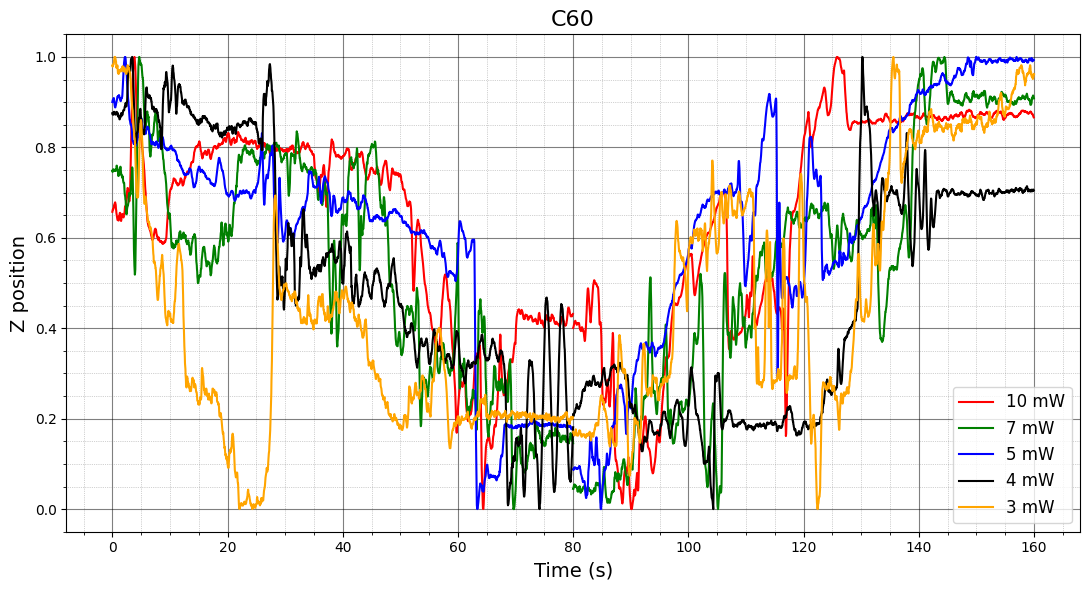

In [18]:
def load_csv(csv_path):
    data = pd.read_csv(csv_path)
    t = data["Time (s)"].values
    z = data["Z_pos (um)"].values
    return t, z

def plot_all(particle, Powers):
    sweep_no = {10:(1,2), 7:(3,4), 5:(5,6), 4:(7,8), 3:(9,10)}
    color = ['r','g','b','k','orange']
    zs = np.zeros(len(Powers),len(t1))

    def merge(t1, z1, t2, z2):
        t2_shifted = t2 + t1[-1]
        t = np.concatenate((t1, t2_shifted))
        z = np.concatenate((z1, z2))
        return t, z
    
    fig, ax = plt.subplots(figsize=(11, 6))
    for i, power in enumerate(Powers):
        t1, z1 = load_csv(fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{particle}_sweep_{sweep_no[power][0]}.csv")
        t2, z2 = load_csv(fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}\{particle}_sweep_{sweep_no[power][1]}.csv")
        t , z  = merge(t1, z1, t2, z2)
        z = (z - z.min()) / (z.max() - z.min())
        zs[i].append(z)
        avg = np.mean(zs, axis = 1)
        ax.plot(t, avg_z, color[i], label=f"{power} mW")

    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("Z position", fontsize=14)
    ax.set_title(f"{particle}", fontsize=16)
    ax.legend(fontsize=12)
    
    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth=0.8, color="black", alpha=0.5)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, color="gray", alpha=0.7)
    
    fig.tight_layout()
    out_loc = fr"A:\LML\Centroid_Data\Absorbance vs Orientation\{particle}"
    fig.savefig(fr"{out_loc}\{particle}_zposition_combined_unnormalied2.png", dpi=500, bbox_inches="tight")
    plt.show()

particle = "C60"
Powers = [10, 7, 5, 4, 3]
#Powers = [10]
plot_all(particle, Powers)

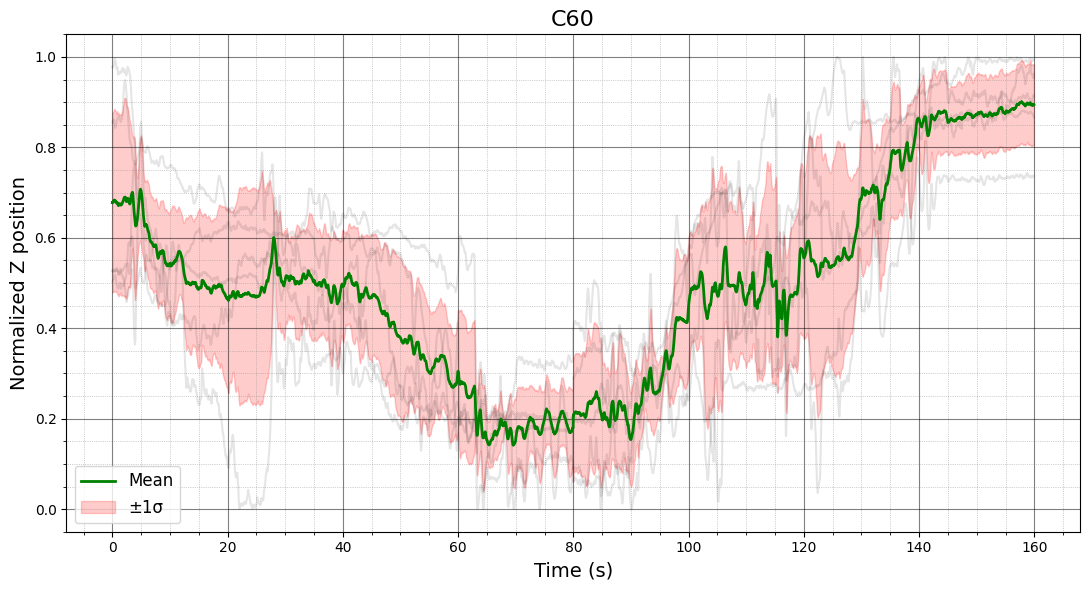

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def load_csv(csv_path):
    data = pd.read_csv(csv_path)
    t = data["Time (s)"].values
    z = data["Z_pos (um)"].values
    return t, z

def merge(t1, z1, t2, z2):
    t2_shifted = t2 + t1[-1]
    t = np.concatenate((t1, t2_shifted))
    z = np.concatenate((z1, z2))
    return t, z

def plot_all(particle, Powers):

    base_path = Path(r"A:\LML\Centroid_Data\Absorbance vs Orientation")/particle

    sweep_no = {10:(1,2), 7:(3,4), 5:(5,6), 4:(7,8), 3:(9,10)}

    series = []
    t_common = None

    for power in Powers:
        s1, s2 = sweep_no[power]

        file1 = base_path / f"{particle}_sweep_{s1}.csv"
        file2 = base_path / f"{particle}_sweep_{s2}.csv"

        if not file1.exists() or not file2.exists():
            print(f"Skipping {power} mW (missing file)")
            continue

        t1, z1 = load_csv(file1)
        t2, z2 = load_csv(file2)
        t, z = merge(t1, z1, t2, z2)
        z = (z - z.min()) / (z.max() - z.min())

        if t_common is None:
            t_common = t

        z_interp = np.interp(t_common, t, z)
        series.append(z_interp)

    if len(series) == 0:
        print("No valid datasets found.")
        return

    series = np.array(series)

    z_mean = np.mean(series, axis=0)
    z_std = np.std(series, axis=0)

    fig, ax = plt.subplots(figsize=(11,6))

    for z in series:
        ax.plot(t_common, z, color="black", alpha=0.1)

    ax.plot(t_common, z_mean, color="green", linewidth=2, label="Mean")
    ax.fill_between(t_common, z_mean - z_std, z_mean + z_std, color="red", alpha=0.2, label="±1σ")

    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("Normalized Z position", fontsize=14)
    ax.set_title(particle, fontsize=16)
    ax.legend(fontsize=12)

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth=0.8, color="black", alpha=0.5)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, color="gray", alpha=0.7)

    fig.tight_layout()
    out_loc = base_path
    #fig.savefig(out_loc/f"{particle}_zposition_combined.png", dpi=600, bbox_inches="tight")

    plt.show()

particle = "C60"
Powers = [10,7,5,4,3]

plot_all(particle, Powers)